In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의


In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [3]:
# 데이터 생성
np.random.seed(2025)
satisfaction = np.random.normal(7.5, 1.5, 1000)
satisfaction = np.clip(satisfaction, 1, 10)
df1 = pd.DataFrame({'score': satisfaction})

In [4]:
df1.describe()

,score
count,1000.000000
mean,7.428690
std,1.392671
min,2.724405
25%,6.469893
50%,7.421731
75%,8.437992
max,10.000000


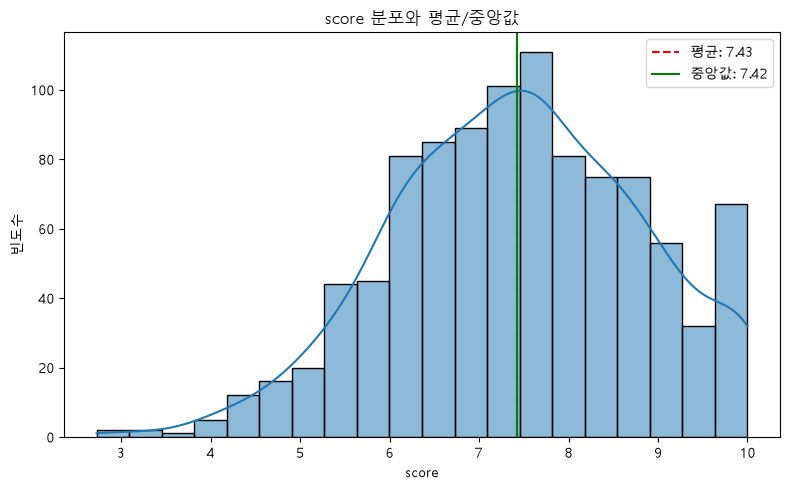

In [ ]:


import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

mean_val = float(df1["score"].mean())
median_val = float(df1["score"].median())

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df1["score"], bins=20, kde=True, ax=ax)

ax.axvline(mean_val, color="red", linestyle="--", label=f"평균: {mean_val:.2f}")
ax.axvline(median_val, color="green", linestyle="-", label=f"중앙값: {median_val:.2f}")

ax.set_title("score 분포와 평균/중앙값")
ax.set_xlabel("score")
ax.set_ylabel("빈도수")
ax.legend()
plt.tight_layout()
plt.show()

평균과 중앙값 사이의 차이는 어느 정도인가요?
▸ 0.01
두 값이 비슷하다면, 이 데이터는 어떤 분포 형태일 가능성이 있을까요? (예: 대칭형, 정규분포 등)
▸ 대칭형
두 값의 차이가 크다면, 그 이유는 무엇일까요?
▸ 이상치가 있어서 평균이 중앙값보다 낮거나 높게 나타나는 경우
어떤 값들이 평균을 끌어내리거나 끌어올렸을까요?
▸ 이상치
최빈값이 평균보다 낮은 경우, 낮은 점수를 준 고객이 많다는 뜻일 수 있습니다. 이 경우 데이터 분포는 어느 쪽으로 치우쳐 있을까요?
▸ 분포는 오른쪽으로 치우쳐 있다.
반대로 최빈값이 평균보다 높은 경우에는 어떤 해석이 가능할까요? 이럴 때 분포가 어떻게 달라질 수 있을까요?
▸ 높은 점수를 준 고객이 많다는 뜻이고 분포는 왼쪽으로 치우쳐 있다.
이 데이터를 바탕으로 고객 만족도를 높이기 위한 마케팅 전략에는 어떤 것들이 있을까요?
▸ 점수를 높게 받은 서비스가 무엇인지 파악하고 해당 서비스는 필수로 가져가며 낮게 준 사유를 분석해서 해당 부분에 대한 보완을 적용한다.

In [8]:
# 데이터 생성
np.random.seed(2025)

# A 지역: 평균 300, 표준편차 50
region_a = np.random.normal(300, 50, 100)

# B 지역: 일반 소득자 + 극단적인 고소득자 포함
region_b = np.concatenate([
    np.random.normal(280, 40, 95),    # 일반 소득자 95명
    np.random.normal(1500, 200, 5)    # 고소득자 5명
])

df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})

In [20]:
print(f"A 지역 평균 {region_a.mean().round(2)}")
print(f"A 지역 중앙값 {np.median(region_a).round(2)}")

print(f"B 지역 평균 {region_b.mean().round(2)}")
print(f"B 지역 중앙값 {np.median(region_b).round(2)}")

A 지역 평균 292.51
A 지역 중앙값 294.32
B 지역 평균 347.59
B 지역 중앙값 287.35


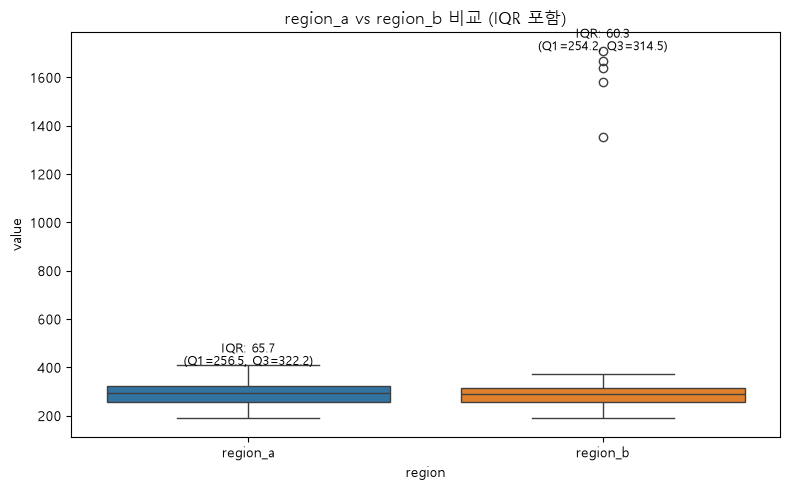

In [22]:
combined = pd.concat([
    pd.DataFrame({"value": region_a, "region": "region_a"}),
    pd.DataFrame({"value": region_b, "region": "region_b"})
], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=combined, x="region", y="value", hue="region", legend=False, ax=ax)
ax.set_title("region_a vs region_b 비교 (IQR 포함)")

# 각 그룹의 Q1, Q3, IQR 계산해서 텍스트로 표시
for i, region_name in enumerate(["region_a", "region_b"]):
    data = combined[combined["region"] == region_name]["value"]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    ax.text(i, data.max() + 2, f"IQR: {iqr:.1f}\n(Q1={q1:.1f}, Q3={q3:.1f})",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

A 지역과 B 지역의 평균 연봉은 어떻게 다른가요?
▸  A 지역(292.51), B 지역(347.59)
두 지역의 평균 차이가 의미하는 바는 무엇인가요?
▸ B 지역에 일부 소득이 높은 사람이 존재함. 
고소득자가 있는 지역의 평균은 어떤 영향을 받을까요?
▸ 평균이 그렇지 않은 지역보다 더 높게 나타난다.
중앙값은 어떠한가요?
▸ 중앙값은 A지역이(294.32), B지역(287.350)로 B지역이 더 낮게 나타남.
평균과 비교했을 때, 중앙값이 더 낮거나 높다면 어떤 해석이 가능할까요?
▸ 평균과 비교했을 때 중앙값이 더 낮다면 높은 쪽에 이상치가 있을 수 있음, 낮게 나타난다면 낮은 쪽의 값이 더 많이 분포해있음.
극단값(고소득자)의 영향은 어디에서 더 크게 나타날까요?
▸ 평균에서 더 영향이 크게 나타남.
평균과 중앙값 중 어떤 지표가 극단값에 더 민감한가요?
▸ 평균값
박스플롯을 통해 어떤 점을 관찰할 수 있나요?
▸ B지역에 이상치가 5건 있는 것으로 확인됨.
이상치(Outlier)는 어떻게 표시되나요?
▸ 동그란 원으로 표기됨.
두 지역의 분포 폭(사분위 범위)은 어떻게 다른가요?
▸ 사분위 범위는 비슷하게 나타남
평균만 보고 판단했을 때 생길 수 있는 오해는 무엇인가요?
▸ B지역이 A지역보다 더 소득이 높다는 오류가 생김.
어떤 경우에는 중앙값이 더 유용한 지표일 수 있을까요?
▸ 이런 경우 중양값이 더 유용한 지표가 될 수 있고 꼭 히스토그램을 통해 확인이 필요할 것 같음.

In [23]:
# 데이터 생성
np.random.seed(2025)  # 재현 가능성을 위해 시드 고정

# 1반: 평균 75, 표준편차 8
class1 = np.random.normal(75, 8, 30)

# 2반: 일반 학생 + 이상값(0점, 130점)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),  # 일반 학생
    [0, 130]                       # 극단적인 이상값
])

df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})

In [ ]:
print(f"A반 평균: {class1.mean().round(2)}")
print(f"B반 평균: {class2.mean().round(2)}")

print(f"A반 최소값: {class1.min()}")
print(f"B반 최소값: {class2.min()}")

print(f"A반 최대값: {class1.max()}")
print(f"B반 최대값: {class2.max()}")


A반 평균: 75.72
B반 평균: 73.73
A반 최소값: 60.68541562198489
B반 최소값: 0.0
A반 최대값: 92.17589258628496
B반 최대값: 130.0


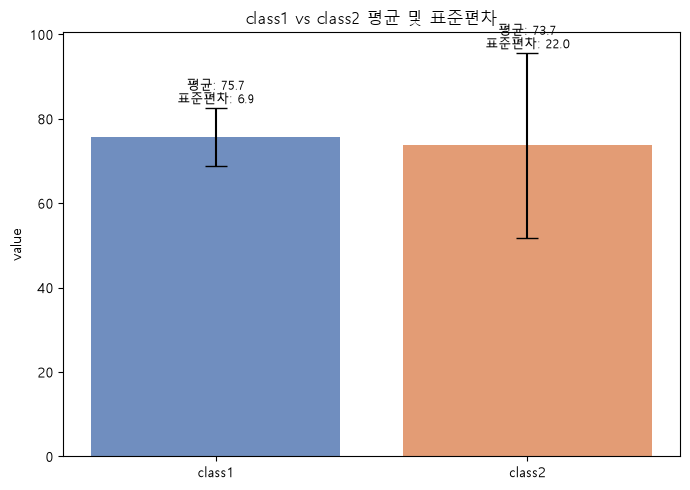

In [30]:
means = [np.mean(class1), np.mean(class2)]
stds = [np.std(class1), np.std(class2)]
labels = ["class1", "class2"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, means, yerr=stds, capsize=8, color=["#4C72B0", "#DD8452"], alpha=0.8)

for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 1, f"평균: {m:.1f}\n표준편차: {s:.1f}", ha="center", fontsize=9)

ax.set_title("class1 vs class2 평균 및 표준편차")
ax.set_ylabel("value")
plt.tight_layout()
plt.show()

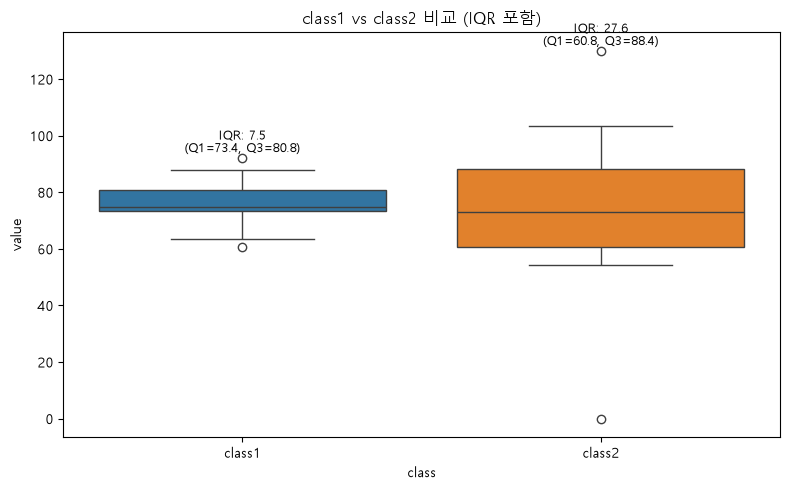

In [29]:
combined = pd.concat([
    pd.DataFrame({"value": class1, "class": "class1"}),
    pd.DataFrame({"value": class2, "class": "class2"})
], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=combined, x="class", y="value", hue="class", legend=False, ax=ax)
ax.set_title("class1 vs class2 비교 (IQR 포함)")

# 각 그룹의 Q1, Q3, IQR 계산해서 텍스트로 표시
for i, class_name in enumerate(["class1", "class2"]):
    data = combined[combined["class"] == class_name]["value"]
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    ax.text(i, data.max() + 2, f"IQR: {iqr:.1f}\n(Q1={q1:.1f}, Q3={q3:.1f})",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

어떤 반의 점수 분산이 더 크고, 왜 그럴까요?
▸ class2의 분산이 더 크다 평균 대비 최소, 최대값의 차이가 커서.
점수 분포의 퍼짐 정도는 어떤 지표로 확인할 수 있을까요?
▸ 표준편차
이상값이 포함되면 표준편차나 범위는 어떻게 달라질까요?
▸ 이상값이 포함된다면 표준편차의 범위는 넓어지게된다.
이상값이 있는 반의 평균은 어떤 영향을 받았나요?
▸ 이상값이 있는 반의 평균은 이상값이 없는 반 평균보다 낮거나 높게 나타난다
극단적으로 낮거나 높은 점수가 평균을 끌어내리거나 끌어올렸나요?
▸ 네
평균과 중앙값의 차이가 의미하는 바는 무엇인가요?
▸ 평균과 중앙값의 차이가 있다면 평균이 이상치에 영향을 받아 중앙값과 차이가 발생하였다.
박스플롯을 통해 이상값은 어떻게 드러나나요?
▸ 이상값은 위 아래로 IQR을 벗어난 곳에 위치하고 있다.
이상값(outlier)은 박스플롯에서 어떤 형태로 나타나나요?
▸ 이상값은 위 아래로 IQR을 벗어난 곳에 위치하고 있다.
두 반의 박스(사분위 범위)는 어떻게 다르게 보이나요?
▸ class2의 사분위가 더 넓게 나타납니다(이상치로 인하여)
평균만 보고 평가했을 때 생길 수 있는 오해는 무엇인가요?
▸ class2 학생들이 class1 학생들보다 성적이 낮다
예를 들어, 교사가 평균 점수만 보고 2반이 부족하다고 판단한다면?
▸ 위에서 언급한 오류를 범하고 있음.
중앙값이나 표준편차 같은 지표와 함께 분석하는 것은 왜 중요할까요?
▸ 이상치 유무를 확인할 수 있고 표준편차가 적절한지 확인하는 것이 표본이 적절한가 판단할 수 있음.

In [38]:
import numpy as np

Q1 = np.quantile(class1, 0.25)
Q3 = np.quantile(class1, 0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 제거한 데이터
class2_clean = class2[(class2 >= lower) & (class2 <= upper)]

print(class2_clean.mean().round(2))

77.01


In [40]:
print(f"A반 평균: {class1.mean().round(2)}")
print(f"B반 평균: {class2_clean.mean().round(2)}")

print(f"A반 최소값: {class1.min()}")
print(f"B반 최소값: {class2_clean.min()}")

print(f"A반 최대값: {class1.max()}")
print(f"B반 최대값: {class2_clean.max()}")

print(f"A반 중앙값: {np.median(class1)}")
print(f"B반 중앙값: {np.median(class2_clean)}")

A반 평균: 75.72
B반 평균: 77.01
A반 최소값: 60.68541562198489
B반 최소값: 64.86674236471373
A반 최대값: 92.17589258628496
B반 최대값: 91.03980444978299
A반 중앙값: 74.75050975133011
B반 중앙값: 74.87763661377056


이상값 제거 전후 평균은 어떻게 달라졌나요?
평균이 중앙값에 가까워졌나요?
▸ 평균이 중앙값에 가까워짐.
이상값 제거가 평균에 어떤 방향으로 영향을 주었나요?
▸ 이상값 제거 시 평균이 중앙값과 가까워지며 표준편차가 한쪽으로 치우치지 않게됨.

왜 IQR을 기준으로 이상값을 판단할까요?
IQR은 데이터를 어떻게 나누고, 어떤 방식으로 이상값을 정의하나요?
▸ IQR은 사분위로 상위 25% 하위 25%를 이상값으로 정의함.
평균이나 표준편차 기준과 비교했을 때 어떤 점이 더 강건할까요?
▸ 이상치를 제거하는 것이 전체적인 평균이나 표준편차 비교 시 더 적절한 비교가 될 수 있다.

이상값은 언제 제거하고, 언제 유지해야 할까요?
분석 목적에 따라 이상값은 중요한 정보가 될 수 있습니다.
▸ 이상값이 실제 오류로 인한 값에 해당하면 삭제하나 해당 값이 실제로 해당하는 값이면 보수적인 관점에서 유지해야한다.

중앙값과 평균은 각각 어떤 상황에서 더 유용한 지표인가요?
이상값이 있을 때 어떤 지표가 더 신뢰할 수 있나요?
▸ 이상값이 있다면 중앙값이 더 신뢰할 수 있는 지표이다.
두 지표를 함께 보면 어떤 장점이 있을까요?
▸ 이상값 유무를 확인할 수 있고 표준편차까지 확인한다면 이상치가 어느 쪽으로 치우쳤는지도 확인할 수 있다.

In [41]:
# 데이터 생성
np.random.seed(2025)
df5 = pd.DataFrame({
    'age': np.random.randint(18, 65, 200),
    'coffee_type': np.random.choice(['아메리카노', '라떼', '카페모카'], 200),
    'size': np.random.choice(['Small', 'Medium', 'Large'], 200),
    'price': np.random.normal(4500, 500, 200),
    'satisfaction': np.random.randint(1, 6, 200)
})

In [42]:
df5.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           200 non-null    int32  
 1   coffee_type   200 non-null    str    
 2   size          200 non-null    str    
 3   price         200 non-null    float64
 4   satisfaction  200 non-null    int32  
dtypes: float64(1), int32(2), str(2)
memory usage: 9.6 KB


숫자처럼 보이지만 사실은 범주형 또는 서열형으로 해석하는 변수가 있다면 무엇일까요?
▸ 해당 숫자가 물리적으로 표현할 수 있는 간격이 존재하지 않고 0은 매우 불만족, 10은 매우 만족과 같이 각 사람마다 느끼는 내용에 따라 다를 수 있음
변수 유형에 따라 적절한 분석 방법이나 시각화 방식은 어떻게 달라질까요?
▸ 서열형은 순서가 있어서 그 순서와 동일하게 배치하고 순서 변경 불가능
명목형은 순서와 상관없이 배치 가능

In [43]:
# 데이터 생성
np.random.seed(202)

temp = np.random.normal(25, 5, 100)
humidity = np.random.normal(60, 10, 100)
sales = temp * 10 - humidity * 2 + np.random.normal(0, 20, 100) + 200

df6 = pd.DataFrame({'temp': temp, 'humidity': humidity, 'sales': sales})

=== 상관계수 행렬 ===
              temp  humidity     sales
temp      1.000000 -0.115936  0.906593
humidity -0.115936  1.000000 -0.390105
sales     0.906593 -0.390105  1.000000


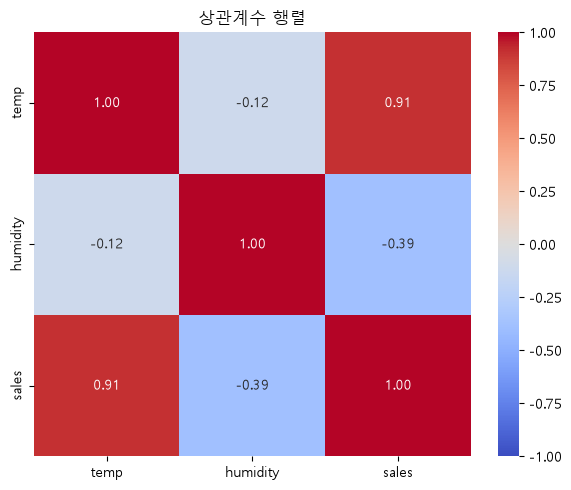

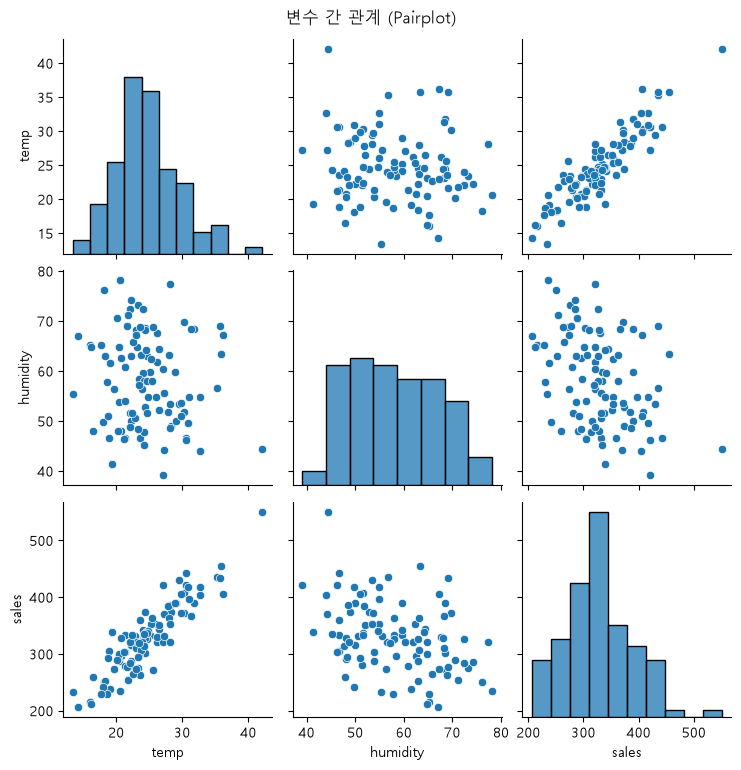

In [44]:
np.random.seed(202)
temp = np.random.normal(25, 5, 100)
humidity = np.random.normal(60, 10, 100)
sales = temp * 10 - humidity * 2 + np.random.normal(0, 20, 100) + 200
df6 = pd.DataFrame({'temp': temp, 'humidity': humidity, 'sales': sales})

# 1. 상관계수 행렬
corr_matrix = df6.corr()
print("=== 상관계수 행렬 ===")
print(corr_matrix)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("상관계수 행렬")
plt.tight_layout()
plt.show()

# 2. pairplot
sns.pairplot(df6)
plt.suptitle("변수 간 관계 (Pairplot)", y=1.02)
plt.show()

🧠 데이터를 어떻게 읽을까요?
출력된 상관계수 행렬을 보고,
어떤 변수와 sales 간의 상관계수가 가장 높은가요?
▸ temp와 상관계수가 높음.
어느 쌍이 양의 상관관계, 어느 쌍이 음의 상관관계인가요?
▸ 양의 상관관계 temp와 sales, 음의 상관관계: humidity와 temp, humidity와 sales

페어플롯에서
어떤 변수 쌍은 직선 형태로 관계가 보이나요?
▸
어떤 변수 쌍은 분산이 크거나 패턴이 없는가요?
▸

상관관계가 반드시 인과관계를 의미하지는 않습니다.
온도와 매출에 상관관계가 있다고 해서, 온도가 매출을 직접적으로 증가시킨다고 볼 수 있을까요?
▸
이 데이터를 바탕으로 어떤 추가 가설이나 실험 설계를 생각해볼 수 있을까요?
▸